## Controlled simple transport model

* Based on the simple transport model

After some imports:

In [1]:
from pymf6.mf6 import MF6
from pymf6tools.plotting import show_heads, show_concentration
from create_model import create_model

we provide the model path and name:

In [2]:
model_path = 'models/pymf6'
name = 'transport'
nam_file = model_path + '/mfsim.nam'

## Inspect the simulation at runtime

Inspect the model by creating an instance of `MF6` from `pymf6`:

In [3]:
mf6 = MF6(nam_file, use_modflow_api=False)

There are many model variables:

In [4]:
len(mf6.vars)

881

Access the simulations:

In [5]:
sim = mf6.simulation

## Flow and transport simulations

Two coupled simulations with two separate `nam` files:

* one for flow `gwf6` and 
* one for transport `gwt6`

In [6]:
sim                                          

modeltype,namefile,modelname
gwf6,transport.nam,TRANSPORT
gwt6,gwt_transport.nam,GWT_TRANSPORT


## Inspect the packages

Simulations have different packages:

In [7]:
sim.models

[Model TRANSPORT 
 15 packages
 49 variables.,
 Model GWT_TRANSPORT 
 12 packages
 42 variables.]

There are also two solution groups, one for each simulation:

In [8]:
sim.solution_groups

[Solution 1 
 1 packages
 68 variables.,
 Solution 2 
 1 packages
 68 variables.]

## Inspect the time discretization 

The time discretization is the same for both simulations:

In [9]:
sim.TDIS

number of variables:,19


In [10]:
sim.TDIS.var_names[:5]

['NPER', 'ITMUNI', 'KPER', 'KSTP', 'INATS']

## Access relevant variables

* Solution variable in the first solution is the head 
* Solution variable in the second solution is the concentration

In [11]:
conc_array = mf6.vars['SLN_2/X'].reshape(10, 10)
wel = mf6.vars['TRANSPORT/WEL-1/BOUND']

We get a hold of the time steps:

In [12]:
steps = mf6.steps()

## Our simple control mechanism

* Linear relationship between the concentration 
  at the right border and the pumping rate

In [13]:
concs_rates = [
    (2.5, -0.6),
    (2.4, -0.5),
    (2.2, -0.4),
    (2.1, -0.3),
    (2.0, -0.2),
    (1.9, -0.1),
]

## Change model variables at runtime

* Iterate over all time steps
* Modify the pumping rate based on the concentration at the right model boundary

In [14]:
for time_step in steps:
    modelled_conc = conc_array[1:-1, -1].max()
    for conc, rate in concs_rates:
        if modelled_conc > conc:
            wel[:] = rate
            break
    else:  # no `break` reached
        wel[:] = 0

## Look at the results

* Highest concentration at the right hand side at the end of the controlled model run

In [15]:
round(conc_array[1:-1, -1].max(), 1)

2.0

## Wells act as a hydraulic barrier

* Heads show that the well pumping reverts the flow direction
* Flow is now from the right model border towards the well

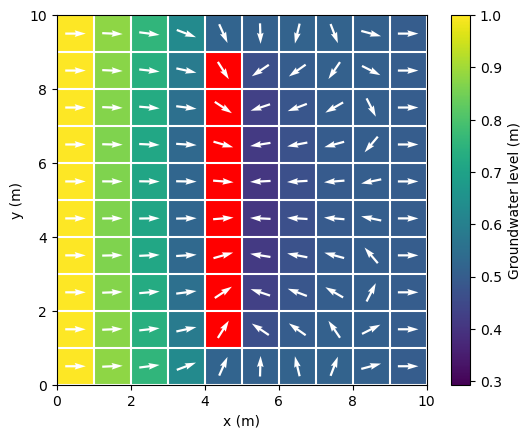

In [16]:
show_heads(model_path=model_path, name=name, show_contours=False,);

## Target concentrations achieved

**The target concentration of about 2 mg/L at the right border has
been achieved.**

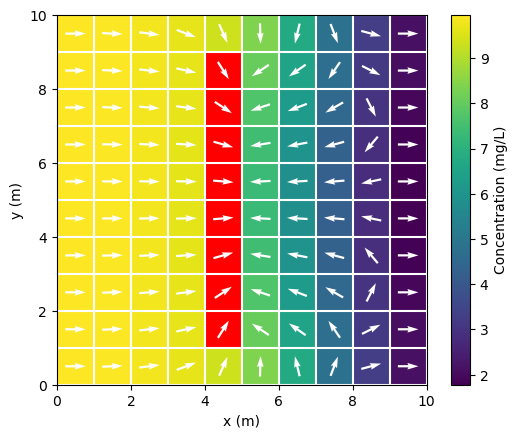

In [17]:
show_concentration(model_path, name, show_contours=False, show_arrows=True);